<center><img src="https://upload.wikimedia.org/wikipedia/commons/c/c3/Python-logo-notext.svg" width="08%" style="vertical-align: top; padding-top: 2px"></center>

<h1><font color='#306998'><center>Application of Neural Networks</center></font></h1>
<center>Kannan Singaravelu, CQF</center>

---

# Deep Sequence Modeling
Deep sequence modeling is essentially applying neural network to problems involving sequential processing of data. Sequence data has memory and comes in many forms such as text, audio, video and financial time series. Thus, requiring a different modeling approaches.

## Recurrent Neural Network
Recurrent Neural Network (RNN) generalize the feedforward neural network with an internal memory state and good at modeling sequence data as it uses sequential memory for prediction. Sequential memory is a mechanism used to identify the sequence patterns. RNNs are faster and use less computational resources as there are less tensor operations. Sequence problems can be broadly categorized into the following types

<img src="http://karpathy.github.io/assets/rnn/diags.jpeg" width="60%" align="center" style="vertical-align: top; padding-top: 23px;">

Diagrammatic Representation of RNNs for Sequence Modeling [<sup>[1]</sup>](#fn1)

## Long Short Term Memory Network
Long Short Term Memory (LSTM) algorithm is a special kind of RNN, explicitly designed to avoid the long-term dependency problem by addressing the problem of short term memory. LSTM models are fundamental to deep learning for financial timeseries and have four interacting layers as given below

<img src="../images/lstm1.png" width="50%" align="center" style="vertical-align: top; padding-top: 23px;">

Diagrammatic Representation of LSTM cell and its operation [<sup>[2]</sup>](#fn2)


# TensorFlow = Tensor + Flow

TensorFlow is an open-source library for numerical computation originally developed by researchers and engineers working at the Google Brain team. It was originally built as a proprietary machine learning system based on deep learning neural networks. 

TensorFlow is made up of two words tensor and flow where Tensor is a multidimensional array and Flow is a graph of operations. Internally, TensorFlow implements machine learning algorithms as a graph of operations on multidimensional array. Tensor is a container for data to store numerical data (almost always) and are a generalization of matrices to an arbitrary number of dimensions which are also called as axis or rank. A tensor is defined by three key attributes: 

* a) Number of axis or ranks `ndim`
* b) Shape `shape` 
* c) Data type `dtype`

TensorFlow is preferred for the following reason

* Easy to build and deploy machine learning models for a beginner.
* Build state of art machine learning models with Keras functional API and model sub classing APIs.
* Supports production of machine learning models, anywhere from CPUs, GPUs to edge devices as well as web servers. 
* APIs available for Python, Java and Go programming languages. 
* Has a very flexible architecture
* Enables easy deployment across different hardware platforms like CPUs, TPUs and GPUs, and computing devices like desktops, servers, mobile devices, and edge devices.

**TensorFlow** is a foundation (base) library that can be used to create deep learning models directly or by using wrapper libraries that simplify the process built on top of it. It is an open source (symbolic math) library for fast numerical computing, created and maintained by Google. Like NumPy, the primary purpose of TensorFlow is to manipulate mathematical expressions over numerical tensors. It can run not only on CPU, but also on GPUs and TPUs, highly-parallel hardware accelerators.

Theano is an open source project developed by now Montreal Institute for Learning Algorithms group at the University of Montreal. However, Theano is considered effectively dead with the team announcing on September 2017 that they would cease all its major development after the release of 1.0 version.

## TensorFlow 2 Installation

Refer [here](https://www.tensorflow.org/install) for installation of latest version of TensorFlow. Tensorflow is tested and supported on the 64-bit systems and has the following system requirements:

* Python 3.8–3.11

* pip 19.0 (or >20.3 for macOS)

* Ubuntu 16.04 or later

* Windows 7 or later (with C++ redistributable)

* macOS 10.12.6 (Sierra) or later (no GPU support)

* WSL2 via Windows 10 19044 or higher including GPUs (Experimental)

## Keras

**Keras** is a deep learning API for Python and is one of the most powerful and easy to use library which runs on top of popular libraries like TensorFlow and Theano for creating deep learning models. It was originally created and developed by Google AI Developer/Researcher, Francois Chollet to facilitate his own research and experiement. He committed and released the first version of Keras to his GitHub on March 2015.

Originally, Keras’ default backend was Theano. At the same time, Google had released TensorFlow. Given the synergies, Keras started supporting TensorFlow as a backend, and slowly TensorFlow became the most popular backend, resulting in TensorFlow being the default backend starting from the release of Keras v1.1.0.

<img src="../images/keras_and_tf(2).png" width="50%" align="center" style="vertical-align: top; padding-top: 23px;"> <br>

<b>Deep Learning Software and Harware Stack</b>

The core data structures of Keras are layers and models. The simplest type of model is the Sequential model, which is a linear stack of layers. For more complex architectures, we should use the Keras functional API, which allows to build arbitrary graphs of layers.

Keras is ideal for prototyping simple concepts and comes with a large community support. It is the default backend now shipped with tensorflow. Refer [here](https://keras.io/api/) for Keras API.

## TensorBoard
TensorBoard is a browser-based visualization tool that let you monitor models during training and gives access to the following features

* Visually monitoring metrics during training
* Visualizing your model architecture
* Visualizing histograms of activations and gradients

In [1]:
# Load the TensorBoard notebook extension
# %load_ext tensorboard

# Many-to-One Sequence Problem

> The input of the LSTM is always a 3D array *[`batch, timesteps, feature`]* <br>
> The output of the LSTM could be a 2D array or 3D array depending upon the `return_sequences argument` <br>
> If `return_sequence` is `False`, the output is a 2D array *[`batch, feature`]* <br>
> If `return_sequence` is `True`, the output is a 3D array  *[`batch, timesteps, feature`]* 

* `batch` is the number of samples in the input data
* `timesteps` are the number of timesteps per sample 
* `feature` correspond to the number of features per timestep

Data with single time-step cannot be considered sequence data in a real sense. Densely connected neural networks have been proven to perform better with single time-step data. Real sequence data consists of multiple time-steps, such as stock prices of past $n$ days, a sentence containing multiple words, and so on.

In many-to-one sequence problems, each input sample has more than one timestep, however the output consists of a single element. Similar to the above examples, each timestep in the input can have one or more features.

**Imports & Settings**

In [2]:
# import tensorflow and keras
import tensorflow 
from tensorflow import keras

# check the tensorflow and keras version
print(f" TensorFlow version is {tensorflow.__version__} \n Keras version is {tensorflow.keras.__version__}")

2025-05-20 19:33:39.680658: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


 TensorFlow version is 2.16.2 
 Keras version is 3.10.0


In [3]:
"""
Created on Wed May 20, 2025 
@author: Kannan Singaravelu
"""
# logging
import logging
logging.getLogger('tensorflow').setLevel(logging.CRITICAL)

# supress warnings
import warnings
warnings.filterwarnings("ignore")

# base libraries
import os
import random
import numpy as np
import pandas as pd
import datetime
from pathlib import Path

# scikit-learn modules
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# tensorflow modules
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, LSTM

from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam, RMSprop 
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator 
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard

# plotting & outputs
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

from pprint import pprint

In [4]:
def set_seeds(seed=2025): 
    random.seed(seed)
    np.random.seed(seed)
    tensorflow.random.set_seed(seed)

## Example : Many-to-One Single Feature 
Let's prepare a sample dataset of 20 samples with 3 timesteps where each timestep will consist of a single feature. The output of each sample will be the sum of these 3 inputs. For example, if our sample consists of a sequence 1,2,3, the output would be sum of these inputs, 1+2+3 = 6.

In [5]:
# create sample dataset
X = np.array([i+1 for i in range(60)])

In [6]:
# reshape into 3D
X = np.array(X).reshape(20,3,1)

In [7]:
print(f'X: {X}')

X: [[[ 1]
  [ 2]
  [ 3]]

 [[ 4]
  [ 5]
  [ 6]]

 [[ 7]
  [ 8]
  [ 9]]

 [[10]
  [11]
  [12]]

 [[13]
  [14]
  [15]]

 [[16]
  [17]
  [18]]

 [[19]
  [20]
  [21]]

 [[22]
  [23]
  [24]]

 [[25]
  [26]
  [27]]

 [[28]
  [29]
  [30]]

 [[31]
  [32]
  [33]]

 [[34]
  [35]
  [36]]

 [[37]
  [38]
  [39]]

 [[40]
  [41]
  [42]]

 [[43]
  [44]
  [45]]

 [[46]
  [47]
  [48]]

 [[49]
  [50]
  [51]]

 [[52]
  [53]
  [54]]

 [[55]
  [56]
  [57]]

 [[58]
  [59]
  [60]]]


In [8]:
# check the shape
X.shape

(20, 3, 1)

Next, we'll create output y, which is the sum of the values in the timesteps

In [9]:
# y is the sum of the values in the timesteps
y = []
for each in X:
    y.append(each.sum())
    
# convert to array
y = np.array(y)

# check the output
print(f'y: {y}')

y: [  6  15  24  33  42  51  60  69  78  87  96 105 114 123 132 141 150 159
 168 177]


In [10]:
# check the shape
y.shape

(20,)

In [11]:
# compile model five
nn = Sequential()
nn.add(LSTM(50, activation='relu', input_shape=(3, 1)))
nn.add(Dense(1))
nn.compile(optimizer='adam', loss='mse')
print(nn.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

None


In [12]:
# fit model
nn.fit(X, y, batch_size=64, epochs=1000, validation_split=0.2, verbose=0)

In [13]:
# predict the outcome
test_input = np.array([70,71,72])
test_input = test_input.reshape((1, 3, 1))
test_output = nn.predict(test_input, verbose=0)
print(test_output)

[[211.98456]]


# Applying Neural Networks to Financial Time Series
Given that we have some understanding of the above deep sequence modeling, let us now apply neural networks to financial timeseries which is a many-to-one sequence problem.

We will retrive the 20 years of SPY price data that we stored earlier for this exercise. We then apply LSTM network given the nature of financial timeseries with a lookback (window size) of 60 days.

## Path to store results

In [14]:
results_path = Path('../data', 'results', 'lstm')
if not results_path.exists():
    results_path.mkdir(parents=True)

## Retrieve data
Download the dataset from [here](https://raw.githubusercontent.com/kannansingaravelu/datasets/refs/heads/main/spy.csv) and place it in the data folder for access.

In [15]:
# Read data from the locally stored file
data = pd.read_csv('../data/spy.csv', index_col=0, parse_dates=True)[['Adj Close']]['2000':'2019']

In [16]:
# Check the shape - has to be 2D
data.shape

(5031, 1)

In [17]:
# Check for missing values
data.isna().sum()

Adj Close    0
dtype: int64

## Visualization 

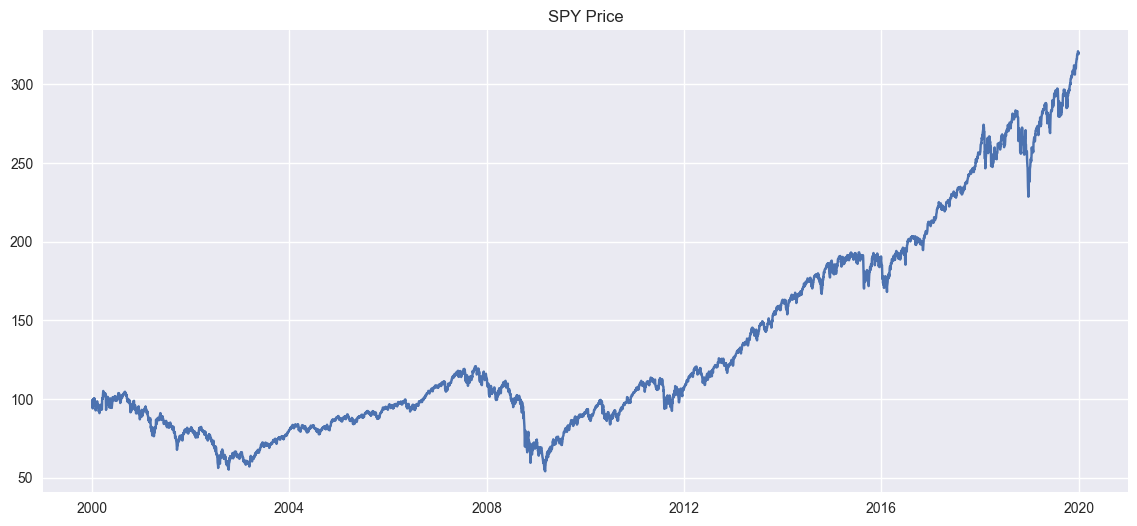

In [18]:
# Visualization 
plt.figure(figsize=(14,6))
plt.title('SPY Price')
plt.plot(data);

## Feature & Target Specification
Features are also known as an independent variable which are used to determine the value of the target variable. In this case, the target variable is the closing price of the stock. 

* The features are the close prices of the stock over the sequence length. 
* The target is the closing price of the stock the next day.

## Train - Test - Split

In [19]:
# Splitting the datasets into training and testing data.
train_data, test_data = train_test_split(data, train_size=0.8, test_size=0.2, shuffle=False)

# Output the train and test data size
print(f"Train and Test Size {len(train_data)}, {len(test_data)}")

Train and Test Size 4024, 1007


## Feature Scaling

In [20]:
# Scale the features MinMax for training and test datasets
scaler = MinMaxScaler(feature_range=(0, 1))
scaledtrain = scaler.fit_transform(train_data)
scaledtest = scaler.transform(test_data)

## Sequence Data Generation
We'll create a function to generate sequence data. In many-to-one sequence problem, the input of the LSTM should be a 3D array and the dataset must be transformed into a structure of samples with input and output components before it can be used to fit a supervised learning model.

The Keras deep learning library provides the TimeseriesGenerator to automatically transform both univariate and multivariate time series data into samples, ready to train deep learning models.

In [21]:
# Sequence length
seqlen = 60

# Generate train and test sequence data
g = TimeseriesGenerator(scaledtrain, scaledtrain, length=seqlen)
g_ = TimeseriesGenerator(scaledtest, scaledtest, length=seqlen)

In [22]:
# check feature set
g[0][0]

array([[[0.32495368],
        [0.29701558],
        [0.29824367],
        ...,
        [0.36678201],
        [0.35877949],
        [0.35447048]],

       [[0.29701558],
        [0.29824367],
        [0.28719142],
        ...,
        [0.35877949],
        [0.35447048],
        [0.35524007]],

       [[0.29824367],
        [0.28719142],
        [0.32648868],
        ...,
        [0.35447048],
        [0.35524007],
        [0.34277439]],

       ...,

       [[0.32768419],
        [0.337557  ],
        [0.32444511],
        ...,
        [0.31665064],
        [0.32948587],
        [0.32438254]],

       [[0.337557  ],
        [0.32444511],
        [0.32999822],
        ...,
        [0.32948587],
        [0.32438254],
        [0.31525849]],

       [[0.32444511],
        [0.32999822],
        [0.34156742],
        ...,
        [0.32438254],
        [0.31525849],
        [0.31897032]]])

In [23]:
# check target 
g[0][1]

array([[0.35524007],
       [0.34277439],
       [0.35108466],
       [0.35539399],
       [0.34985372],
       [0.3452368 ],
       [0.3516236 ],
       [0.35631713],
       [0.3533932 ],
       [0.35123859],
       [0.33092464],
       [0.32092132],
       [0.28029288],
       [0.30368507],
       [0.32199855],
       [0.31538083],
       [0.31876693],
       [0.3110721 ],
       [0.34015826],
       [0.33192476],
       [0.32953945],
       [0.32507646],
       [0.33477197],
       [0.3203055 ],
       [0.30368507],
       [0.3089177 ],
       [0.31738163],
       [0.31207227],
       [0.30645528],
       [0.29075815],
       [0.30630125],
       [0.31384193],
       [0.3259997 ],
       [0.33292494],
       [0.32538437],
       [0.31661237],
       [0.30553193],
       [0.3002993 ],
       [0.29014244],
       [0.30122276],
       [0.28937252],
       [0.29014244],
       [0.3123033 ],
       [0.31384193],
       [0.32615396],
       [0.3386192 ],
       [0.33507956],
       [0.331

In [24]:
# Verify size
for i in range(len(g)):
    a, b = g[i]
    print(a.shape, b.shape)

(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(128, 60, 1) (128, 1)
(124, 60, 1) (124, 1)


## Building a LSTM Model
First, we define the LSTM Recurrent Neural Network by initializing the `Sequential` API. We'll add more `LSTM` layers and adjust the `Dropout` in order to improve the accuracy of our model. Finally, a `Dense` layer is used as output layer.

Next, we compile and train the model defined above. Iteratively, we can increase or decrease the epochs and batch size to get more accuracy. 

Note: _For more complex models involving multiple inputs or outputs, or where layer sharing is required, it's best to use the `Functional` API. It offers greater flexibility and control over the model architecture compared to the Sequential API._ 

In [25]:
# # Create a model
# def build_model(hu=256, input_shape=None): 

#     tensorflow.keras.backend.clear_session()   
    
#     # instantiate the model
#     model = Sequential()
    
#     # add first lstm layer
#     model.add(LSTM(units=hu*2, 
#                    input_shape=input_shape, 
#                    activation = 'elu', 
#                    return_sequences=True, name='LSTM1'))
    
#     # add first dropout layer
#     model.add(Dropout(0.4, name='Drouput1'))
    
#     # add second lstm layer
#     model.add(LSTM(units=hu, 
#                    activation = 'elu', 
#                    return_sequences=True, 
#                    name='LSTM2'))
    
#     # add second dropout layer
#     model.add(Dropout(0.4, name='Drouput2'))
    
#     # add third lstm layer
#     model.add(LSTM(units=hu, 
#                    activation = 'elu', 
#                    return_sequences=False, 
#                    name='LSTM3'))
    
#     # add output layer
#     model.add(Dense(units=1, name='Output'))             
    
#     # specify optimizer separately (preferred method))
#     opt = Adam(learning_rate=0.001, epsilon=1e-08)       
    
#     # model compilation
#     model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    
#     return model

In [26]:
# lstm network
# model = build_model(hu=10, input_shape=(seqlen, 1))

In [63]:
# Create a model
def create_model(hu=256, input_shape=None):

    tensorflow.keras.backend.clear_session()   
    
    # using functional api
    inputs = Input(shape=input_shape)
    lstm = LSTM(units=hu, activation = 'relu', return_sequences=False, name='LSTM')(inputs)
    output = Dense(units=1, name='Output')(lstm)
    model = Model(inputs=inputs, outputs=output)

    # specify optimizer separately (preferred method))
    opt = Adam(learning_rate=0.001, epsilon=1e-08)      
    
    # model compilation
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    
    return model

In [64]:
# lstm network
model = create_model(hu=32, input_shape=(seqlen, 1))

In [65]:
# summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
# plot_model(model, to_file='../images/model.png', show_shapes=True, show_layer_names=True)

### Train the model

In [67]:
# Specify callback functions
model_path = (results_path / 'model.keras').as_posix()
logdir = os.path.join("../tensorboard/logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

my_callbacks = [
    EarlyStopping(patience=20, monitor='loss', mode='min', verbose=1, restore_best_weights=True),
    ModelCheckpoint(filepath=model_path, verbose=1, monitor='loss', save_best_only=True),
    TensorBoard(log_dir=logdir, histogram_freq=1)
]

In [68]:
# Model fitting
history = model.fit(g, 
                    epochs=500, 
                    verbose=1,
                    callbacks=my_callbacks, 
                    shuffle=False)

Epoch 1/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0530 - mae: 0.2076
Epoch 1: loss improved from inf to 0.07668, saving model to ../data/results/lstm/model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0538 - mae: 0.2088
Epoch 2/500
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0035 - mae: 0.0477
Epoch 2: loss improved from 0.07668 to 0.00395, saving model to ../data/results/lstm/model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0036 - mae: 0.0477
Epoch 3/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0058 - mae: 0.0556
Epoch 3: loss did not improve from 0.00395
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0063 - mae: 0.0573
Epoch 4/500
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0069 - mae: 0.0711
Epoch 4: loss did not improve from 0.00395
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0068 - mae: 0.0708
Epoch 5/500
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0069 - mae: 0.0725
Epoch 5: loss did not improve from 0.00395


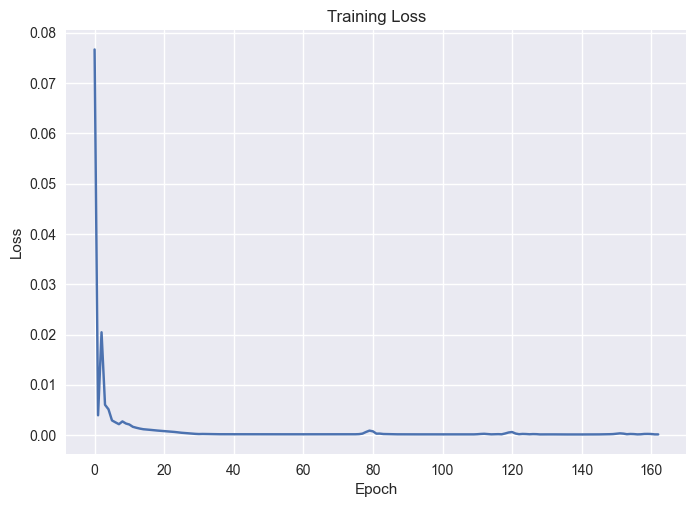

In [69]:
# Plot training loss
plt.plot(history.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss');

### Visualize Learning Process
We'll use TensorBoard to track the learning experiements. You can either use the VS code plugin or the command line interface to launch TensorBoard.

Open the Command Palette (Ctrl+Shift+P) in vscode and launch TensorBoard. Alternatively, you can use the following command in the terminal within the sb3 folder:

``` bash
tensorboard --logdir=../tensorboard/logs
```

Alternatively, you can visualize the results using the following command on Jupyter Notebook

In [70]:
# %tensorboard --logdir ../tensorboard/logs

### Load Saved Model
We'll now load the saved model can by calling the load_model() function and passing the filepath. The function returns the model with the same architecture and weights and avoid tuning the model everytime.

In [71]:
# load model - os.path.abspath(model_path)
model = tensorflow.keras.models.load_model(model_path)

# summarize model
model.summary()

# evaluate the model
score = model.evaluate(g_, verbose=0)
print(f'{model.metrics_names[0]}, {score[0]*100:.4}')
print(f'{model.metrics_names[1]}, {score[1]*100:.4}')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,157 (51.40 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,772 (34.27 KB)

loss, 0.6131
compile_metrics, 6.335


### Evaluate model performance

In [75]:
# Prediction
predictions = model.predict(g_)
predictions_rescaled = scaler.inverse_transform(predictions)

# Actual test values
actual = scaler.inverse_transform(scaledtest[seqlen:])

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


In [76]:
# Evaluation
mse = np.sqrt(mean_squared_error(actual, predictions_rescaled))
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 10.8941


### Plot results

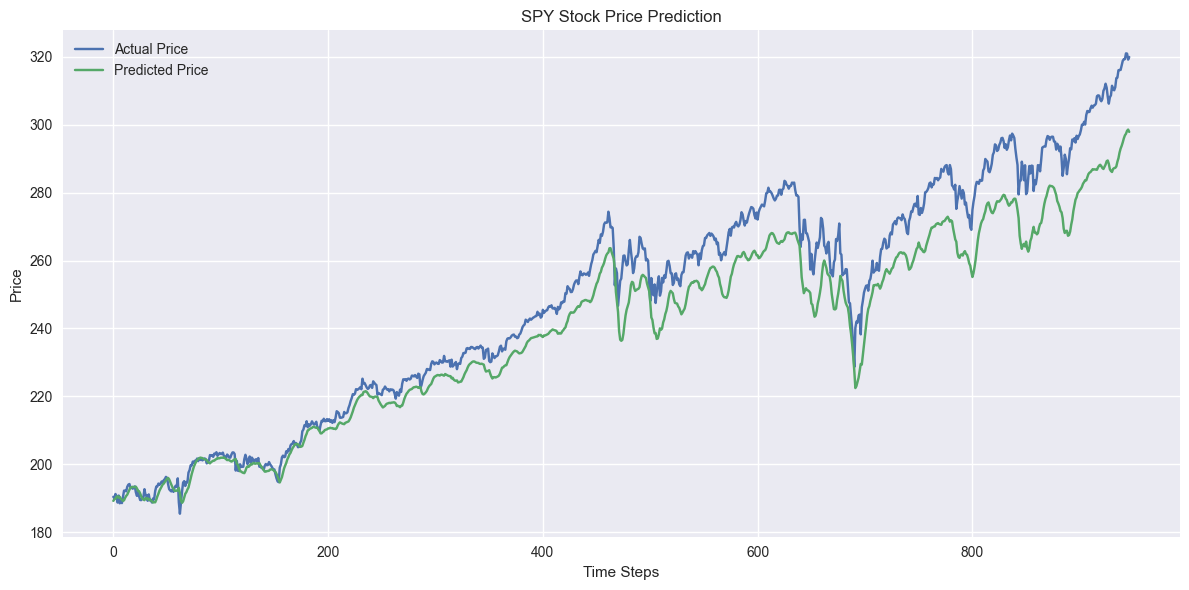

In [77]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(actual, label='Actual Price')
plt.plot(predictions_rescaled, label='Predicted Price')
plt.title('SPY Stock Price Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Print the R-square
print(f'R-square: {r2_score(actual, predictions_rescaled):0.4}')

R-square: 0.8977


# References

[1] <span id="fn1"> Andrej Karpathy (2015), The Unreasonable Effectiveness of Recurrent Neural Networks </span>

[2] <span id="fn2"> Kannan Singaravelu (2022), Introduction to Deep Learning & Neural Networks, Lecture Slide #84 </span>

[3] [Keras API](https://keras.io)

[4] [TensorFlow API](https://www.tensorflow.org)

[5] [Scikit-Learn Preprocessing](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)

---
 Python Labs by [Kannan Singaravelu](https://www.linkedin.com/in/kannansi/)